<a href="https://colab.research.google.com/github/Jamgri/2025_Intro_Python/blob/main/FEEDBACK_James_Grillon.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In this feedback I wanted to see if i could add more information on the map of the Hurricane Florence (W3_S2). For that I started by looking at the data we had. On the map that we've produced for the exercise we only had the USA. So i started my putting the Us map on a projection with other contries.Using the following code :

In [ ]:
df_web = df.to_crs(epsg=3857)
res_web = res_intersection.to_crs(epsg=3857)

After that i've tried to intergrate all the data we had in our dataset. After projecting the map i've seen that it wasn't readable we all the information so I needed to select only a part of it. I've decided to use the diffent storm types we had. For that i've decided to assign a diffrent color for each type using the following code :

In [ ]:
type_colors = {
    'Potential Tropical Cyclone': '#87CEFA',  # bleu clair
    'Tropical Depression': '#00BFFF',        # bleu
    'Tropical Storm': '#1E90FF',             # bleu foncé
    'Hurricane': '#FF4500'                   # rouge-orange
}
res_web['color'] = res_web['Type'].map(type_colors).fillna('#D3D3D3')  # gris clair pour inconnus

Another information i've tried to add on my map is the wind speed of the hurricane. For that I've tried to change to size of the points of the map using the followong code :

In [ ]:
res_web.plot(
    ax=ax,
    facecolor=res_web['color'],
    marker='*',
    markersize=res_web['Wind'].astype(float) * 1.5,  # taille selon vent
    label='Hurricane Florence'
)

On the projected map we couldn't see the diffence between all the points. So I've tried zooming on the area of the hurricane to see if it was better.

In [ ]:
ax.set_title("Hurricane Florence (2018) Path Across the US (Marker Size = Wind Speed)", fontsize=24)
ax.axis('off')

# Zoom sur la zone de l'ouragan
minx, miny, maxx, maxy = res_web.total_bounds
margin_x = (maxx - minx) * 0.2
margin_y = (maxy - miny) * 0.2
ax.set_xlim(minx - margin_x, maxx + margin_x)
ax.set_ylim(miny - margin_y, maxy + margin_y)

plt.show()

We still can't see the diffrence between the points but i've found that that layout was better so I kept the zoom of the area. The final result is with the to diffent maps one next to the other.

In [1]:
!pip install --upgrade pyshp

!pip install --upgrade shapely

!pip install --upgrade descartes

!pip install --upgrade rtree

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 507.6/507.6 kB 9.2 MB/s eta 0:00:00


In [2]:
!pip install --upgrade geopandas

In [3]:
import pooch
# Download the data used in this notebook
data = pooch.retrieve('https://unils-my.sharepoint.com/:u:/g/personal/tom_beucler_unil_ch/EZQnP79VVtROtOlxw5QpfoYBtPG54sb4CZ2vzlg0bKkPew?download=1',
                          known_hash='200a740d0e448aa9e4e03d8a9965a70f228442a2da28d804c8e2337d0ef9749e',
                          processor=pooch.Unzip()
                          )

Unzipping contents of '/root/.cache/pooch/3d43e48bb7d0d0370db00be3096108fe-EZQnP79VVtROtOlxw5QpfoYBtPG54sb4CZ2vzlg0bKkPew' to '/root/.cache/pooch/3d43e48bb7d0d0370db00be3096108fe-EZQnP79VVtROtOlxw5QpfoYBtPG54sb4CZ2vzlg0bKkPew.unzip'


In [7]:
pip install contextily

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 22.3/22.3 MB 84.5 MB/s eta 0:00:00


In [4]:
# And ignore warnings
import warnings
warnings.filterwarnings('ignore')

In [12]:
import geopandas as gpd
import matplotlib.pyplot as plt
import contextily as ctx
import matplotlib.patches as mpatches
import pandas as pd

In [10]:
# Find the index of the country file
countryindex = next(i for i, f in enumerate(data) if 'gz_2010_us_040_00_5m.json' in f)
# Find the index of the Florence cyclone
florenceindex = next(i for i, f in enumerate(data) if 'florence.csv' in f)

# Read data with the geopandas function
# The path to the file should be /content/data/hurricane-data/gz_2010_us_040_00_5m.json

path = data[countryindex]
country =gpd.read_file(path)

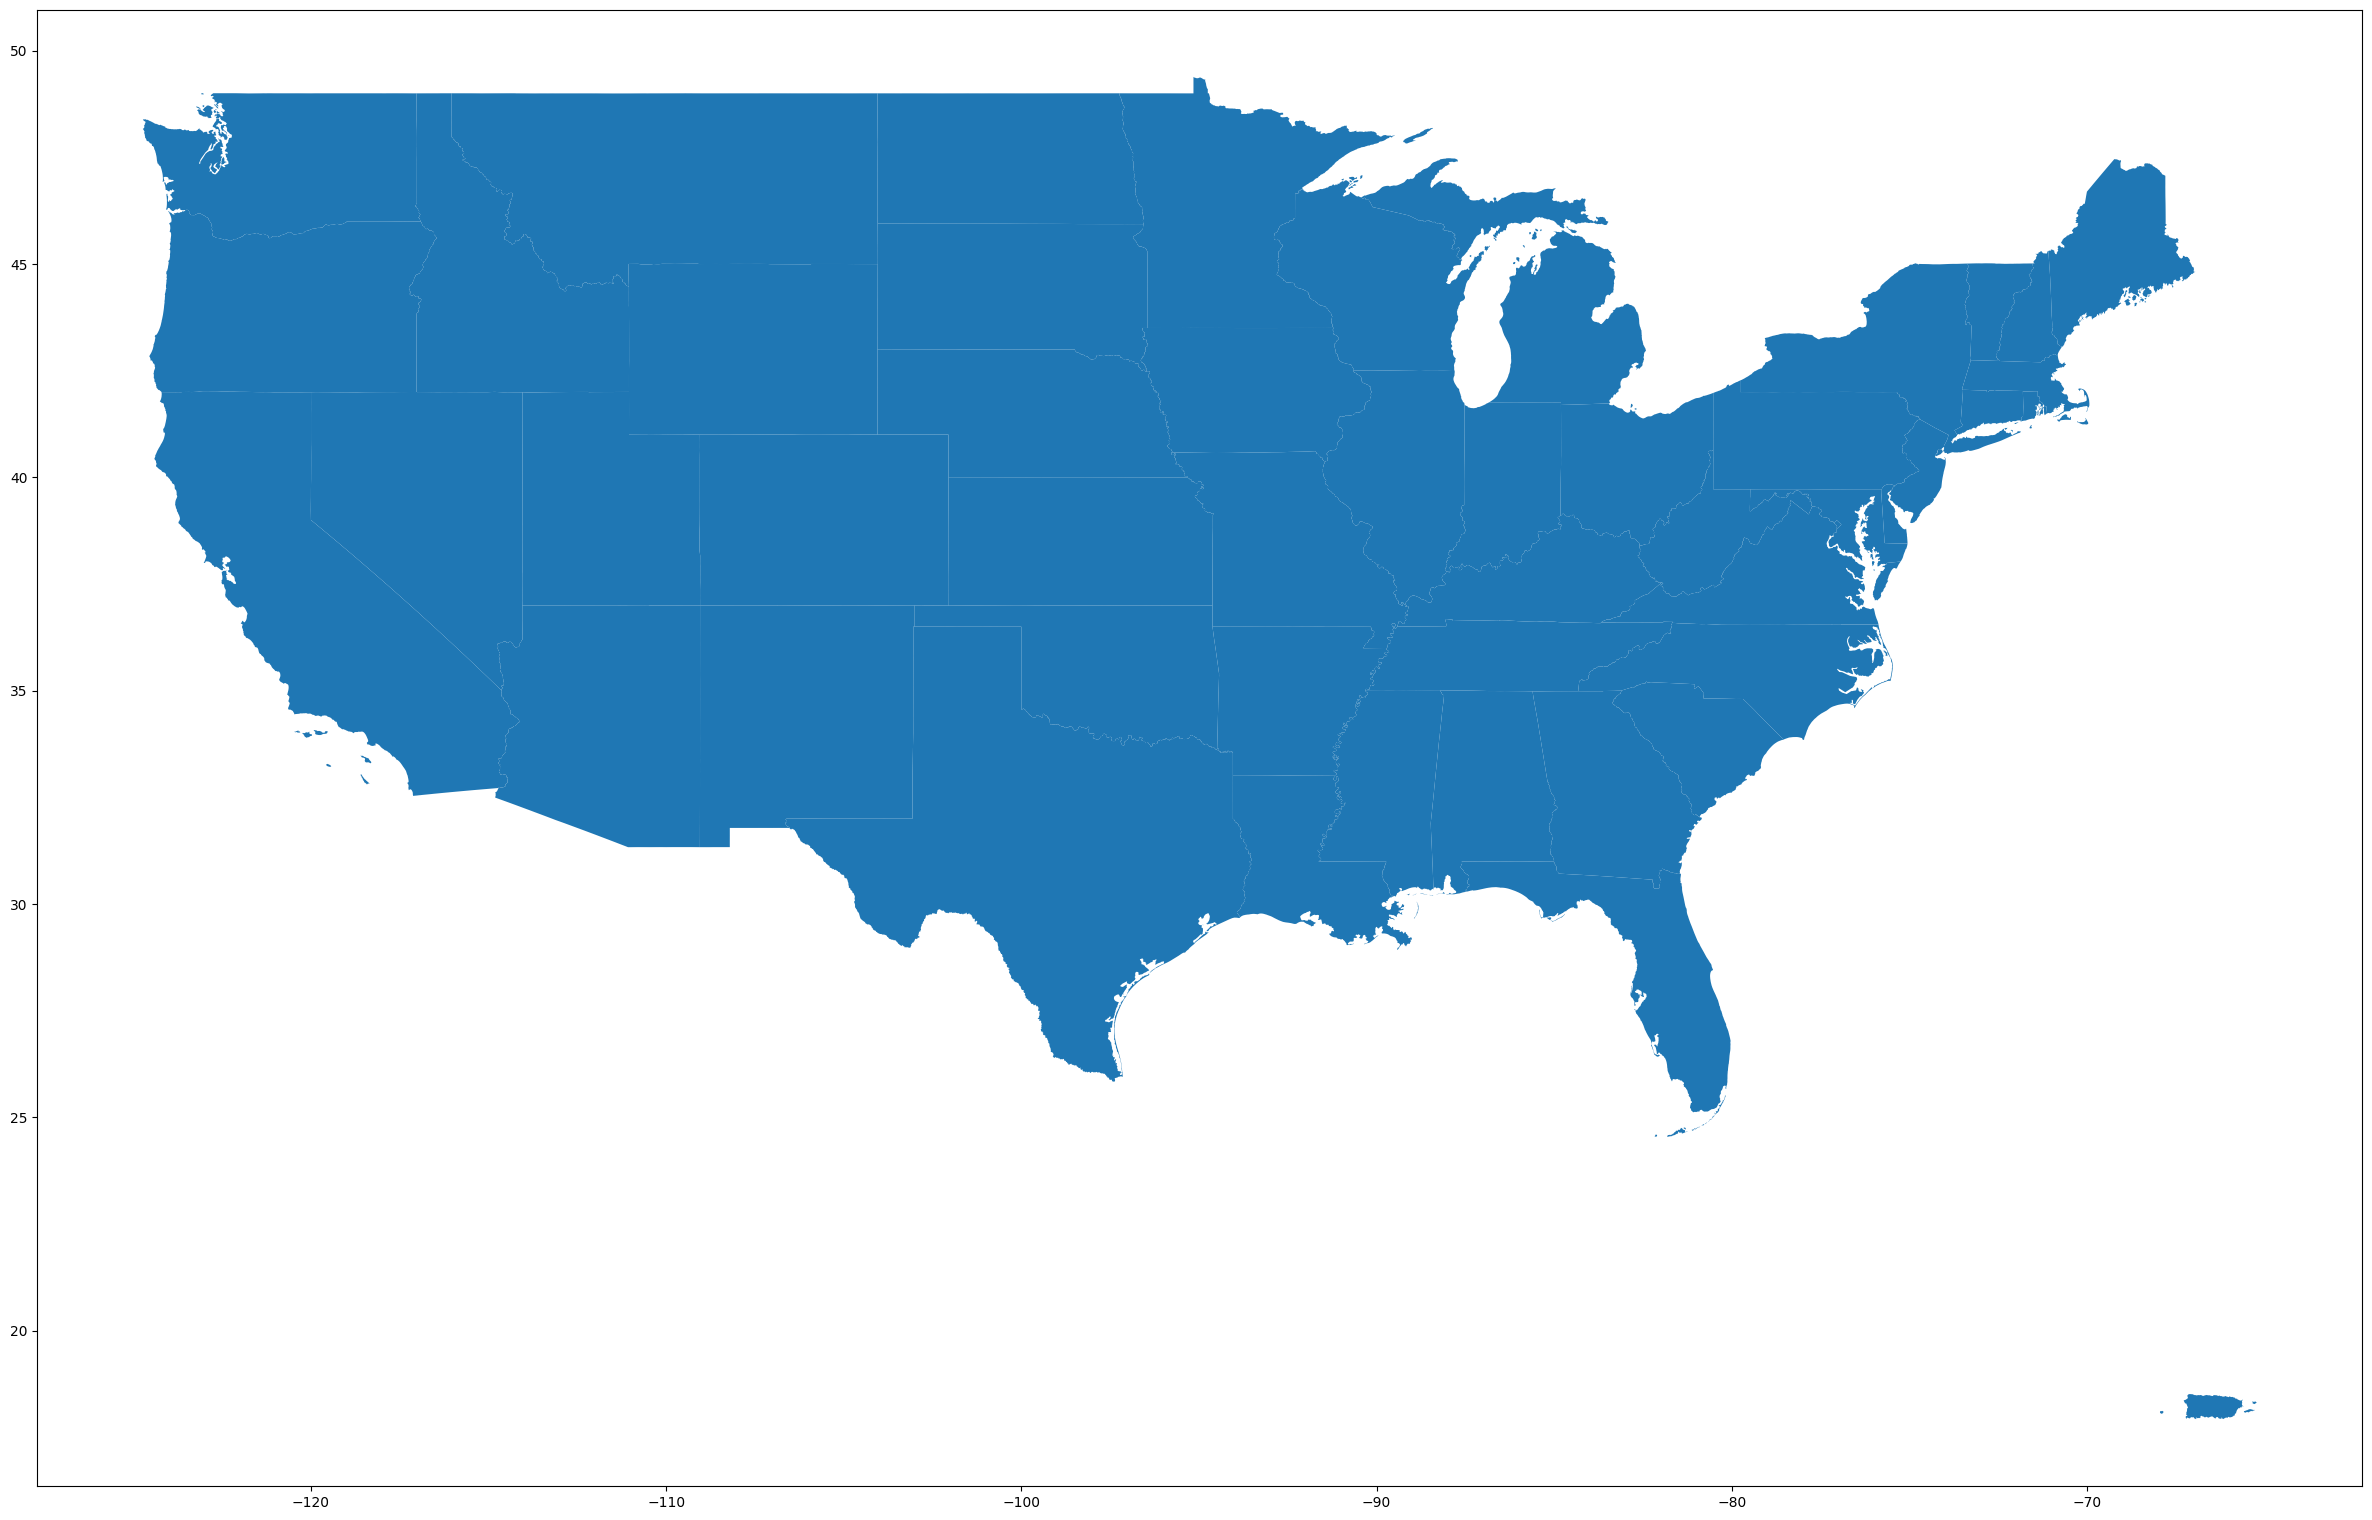

In [15]:
# Plot the US states (Alaska and Hawaii excluded)
country[country['NAME'].isin(["Alaska", "Hawaii"]) == False].plot(figsize=(30, 20))

# Read in the hurricane florence data, change the longitude, and have a look at the hurricane florence dataframe
tc_path = data[florenceindex]
florence = pd.read_csv(tc_path)
florence = florence.drop(['AdvisoryNumber', 'Forecaster', 'Received'], axis=1)
florence['Long'] = 0 - florence['Long']

# Create a geodataframe from the hurricane florence dataframe
gdf_florence = gpd.GeoDataFrame(florence, geometry=gpd.points_from_xy(florence.Long, florence.Lat))



And that's the final map with the ameliorations

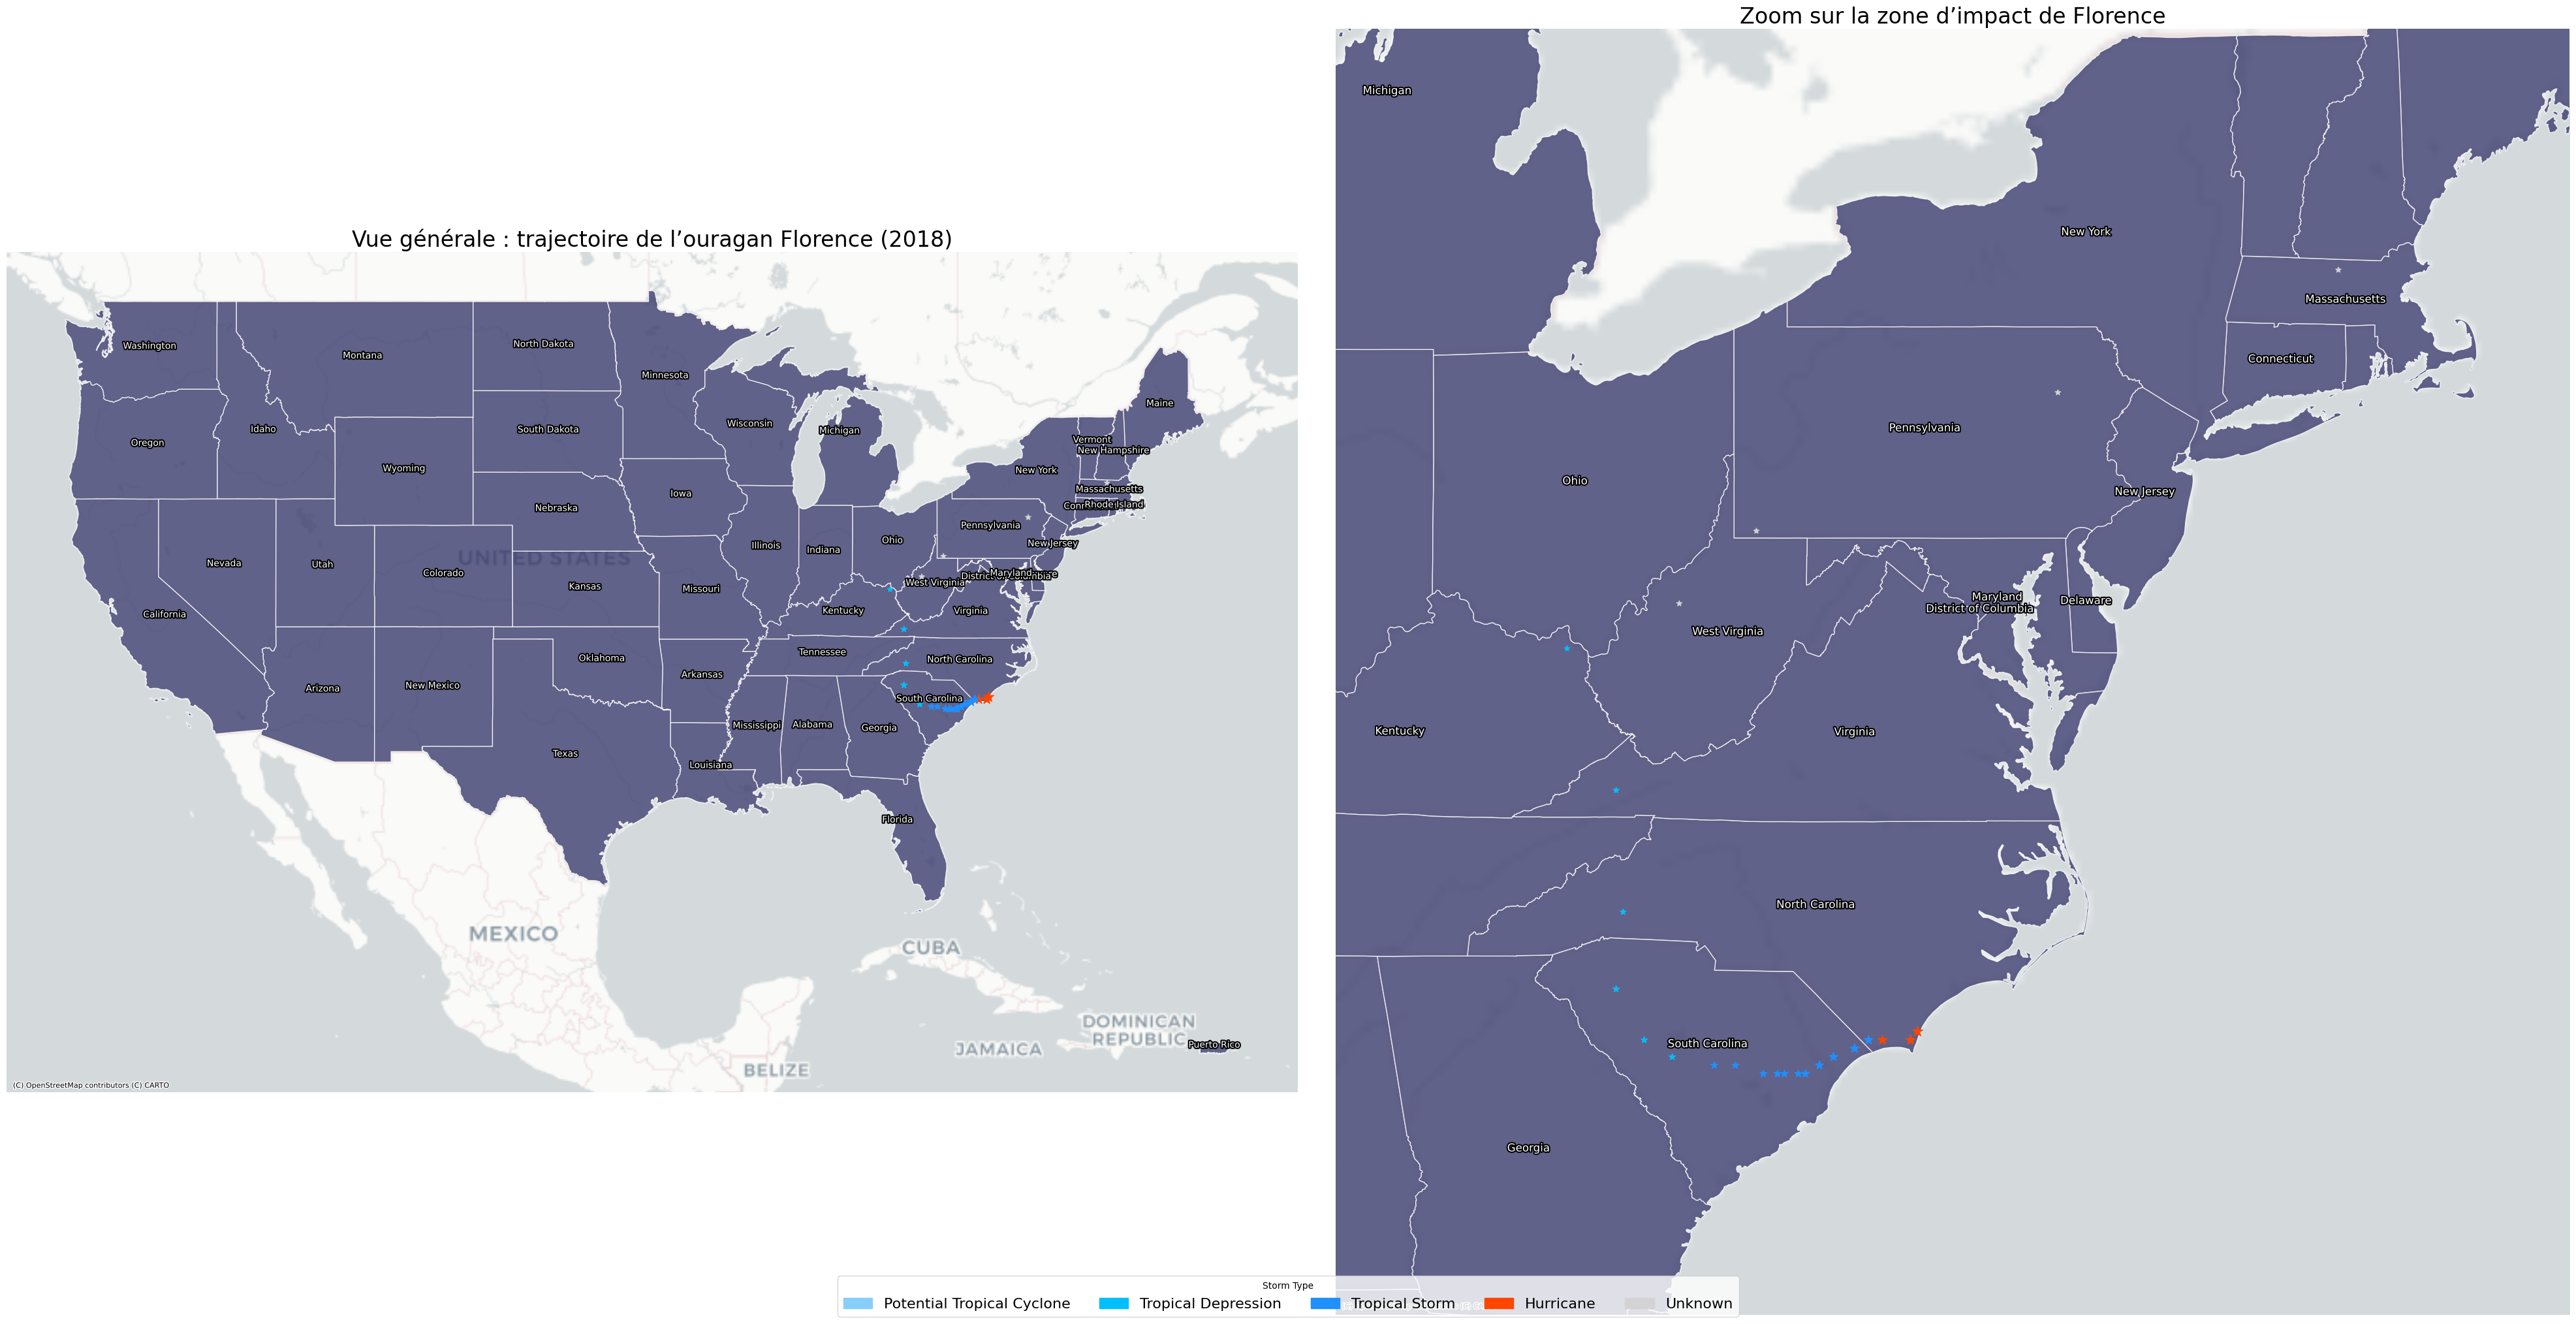

In [20]:
import geopandas as gpd
import matplotlib.pyplot as plt
import contextily as ctx
import matplotlib.patches as mpatches

# --- Filtrer les états US sans Alaska et Hawaii
df = country[~country["NAME"].isin(["Alaska", "Hawaii"])].copy()
df = df.to_crs(epsg=5070)  # US Albers

# --- Définir CRS pour gdf_florence si nécessaire
if gdf_florence.crs is None:
    gdf_florence.set_crs(epsg=4326, inplace=True)

# --- Transformer Florence dans la même projection
gdf_florence_proj = gdf_florence.to_crs(df.crs)

# --- Intersection pour n'avoir que les points à l'intérieur des USA
res_intersection = gdf_florence_proj.overlay(df, how='intersection')

# --- Projection Web Mercator pour Contextily
df_web = df.to_crs(epsg=3857)
res_web = res_intersection.to_crs(epsg=3857)

# --- Créer une colormap selon le type de l’ouragan
type_colors = {
    'Potential Tropical Cyclone': '#87CEFA',
    'Tropical Depression': '#00BFFF',
    'Tropical Storm': '#1E90FF',
    'Hurricane': '#FF4500'
}
res_web['color'] = res_web['Type'].map(type_colors).fillna('#D3D3D3')

# --- Créer la figure avec deux sous-graphiques
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(40, 20))


# Carte 1 : Vue générale

df_web.plot(ax=ax1, color='#3B3C6E', edgecolor='white', alpha=0.8)
res_web.plot(
    ax=ax1,
    facecolor=res_web['color'],
    marker='*',
    markersize=res_web['Wind'].astype(float) * 1.5,
    label='Hurricane Florence'
)
ctx.add_basemap(ax1, source=ctx.providers.CartoDB.Positron)
ax1.set_title("Vue générale : trajectoire de l’ouragan Florence (2018)", fontsize=24)
ax1.axis('off')


for idx, row in df_web.iterrows():
    centroid = row.geometry.centroid
    ax1.annotate(
        text=row['NAME'],
        xy=(centroid.x, centroid.y),
        ha='center',
        fontsize=10,
        color='white',
        path_effects=[plt.matplotlib.patheffects.withStroke(linewidth=3, foreground="black")]
    )


# Carte 2 : Zoom sur la zone

df_web.plot(ax=ax2, color='#3B3C6E', edgecolor='white', alpha=0.8)
res_web.plot(
    ax=ax2,
    facecolor=res_web['color'],
    marker='*',
    markersize=res_web['Wind'].astype(float) * 1.5
)
ctx.add_basemap(ax2, source=ctx.providers.CartoDB.Positron)


minx, miny, maxx, maxy = res_web.total_bounds
margin_x = (maxx - minx) * 0.3
margin_y = (maxy - miny) * 0.3
ax2.set_xlim(minx - margin_x, maxx + margin_x)
ax2.set_ylim(miny - margin_y, maxy + margin_y)

ax2.set_title("Zoom sur la zone d’impact de Florence", fontsize=24)
ax2.axis('off')


visible_states = df_web.cx[minx:maxx, miny:maxy]
for idx, row in visible_states.iterrows():
    centroid = row.geometry.centroid
    ax2.annotate(
        text=row['NAME'],
        xy=(centroid.x, centroid.y),
        ha='center',
        fontsize=12,
        color='white',
        path_effects=[plt.matplotlib.patheffects.withStroke(linewidth=3, foreground="black")]
    )


patches = [mpatches.Patch(color=c, label=t) for t, c in type_colors.items()]
patches.append(mpatches.Patch(color='#D3D3D3', label='Unknown'))
fig.legend(handles=patches, fontsize=16, title="Storm Type", loc='lower center', ncol=5)

plt.tight_layout()
plt.show()


I've decided to add more features to the map we've done during the lesson to see if we could extraxt more information out of it. The only other usefull element i've finaly added is the type of storm which is indicated by the diffrent colors on the map. The other imformation didn't show well on the map (the wind speed per example)

I've also improved the layout by adding the other countries on the general map and then by zooming on the area of the hurricane so we can see better it trajectory and the strom type evolution.

This exercise was interesting because it showed me that we can't put all the information on the same map. We need to make a selection so eveything is visible and readble on the figure.